# Token Score vs Political Leaning — EasyPortrait

Relationship between **image token ideology scores** (image mean, foreground mean, background mean, last prompt token) from `results/token_scoring/{model}/easyportrait/prompt_token_fg_bg_stats_*.csv` and **LLM-labelled political leaning** (from `results/prompt_generation/{model}/`).

In [12]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_context("talk")
sns.set_style("whitegrid")
%matplotlib inline

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

## 1. Load & Merge Data

Merge the fg/bg token-stats CSV with the prompt-generation JSONL on `record_id`.

In [13]:
MODELS = ["gemma4", "qwen3_vl"]
CSV_PROBE = "textual_ideology_headwise_linear"
TOKEN_STATS_DIR = os.path.join(ROOT, "results", "token_scoring")
PROMPT_GEN_DIR  = os.path.join(ROOT, "results", "prompt_generation")

dfs = {}

for model in MODELS:
    csv_path = os.path.join(
        TOKEN_STATS_DIR, model, "easyportrait",
        f"prompt_token_fg_bg_stats_{CSV_PROBE}.csv",
    )
    jsonl_dir = os.path.join(PROMPT_GEN_DIR, model)
    jsonl_candidates = sorted([
        f for f in os.listdir(jsonl_dir) if f.startswith("easyportrait_") and f.endswith(".jsonl")
    ])
    if not jsonl_candidates:
        print(f"{model}: no JSONL found in {jsonl_dir}")
        continue
    jsonl_name = jsonl_candidates[-1]
    jsonl_path = os.path.join(jsonl_dir, jsonl_name)
    print(f"{model}: CSV={os.path.basename(csv_path)}  JSONL={jsonl_name}")

    tk_df = pd.read_csv(csv_path)
    records = []
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    pg_df = pd.DataFrame(records)

    merge_cols = ["record_id", "political_label", "political_confidence", "political_score"]
    available = [c for c in merge_cols if c in pg_df.columns]
    merged = tk_df.merge(pg_df[available], on="record_id", how="inner")
    merged = merged.dropna(subset=["political_label", "political_confidence", "political_score"])
    dfs[model] = merged
    print(f"  {len(merged)} records merged\n")

    for col in ["image_mean", "image_fg_mean", "image_bg_mean", "all_last_token_score"]:
        if col in merged.columns:
            print(f"  {col}:  mean={merged[col].mean():.4f}  std={merged[col].std():.4f}")

gemma4: CSV=prompt_token_fg_bg_stats_textual_ideology_headwise_linear.csv  JSONL=easyportrait_500samples_max512tok.jsonl
  466 records merged

  image_mean:  mean=0.1436  std=0.1996
  image_fg_mean:  mean=0.0631  std=0.2267
  image_bg_mean:  mean=0.2211  std=0.1863
  all_last_token_score:  mean=0.0738  std=0.0670
qwen3_vl: CSV=prompt_token_fg_bg_stats_textual_ideology_headwise_linear.csv  JSONL=easyportrait_500samples_max512tok.jsonl
  500 records merged

  image_mean:  mean=0.1033  std=0.1132
  image_fg_mean:  mean=0.0886  std=0.1433
  image_bg_mean:  mean=0.1207  std=0.1108
  all_last_token_score:  mean=0.2410  std=0.0295


## 2. Pairwise Correlations

Correlation matrix among image token scores (image mean, fg mean, bg mean, last prompt token) and LLM political score.

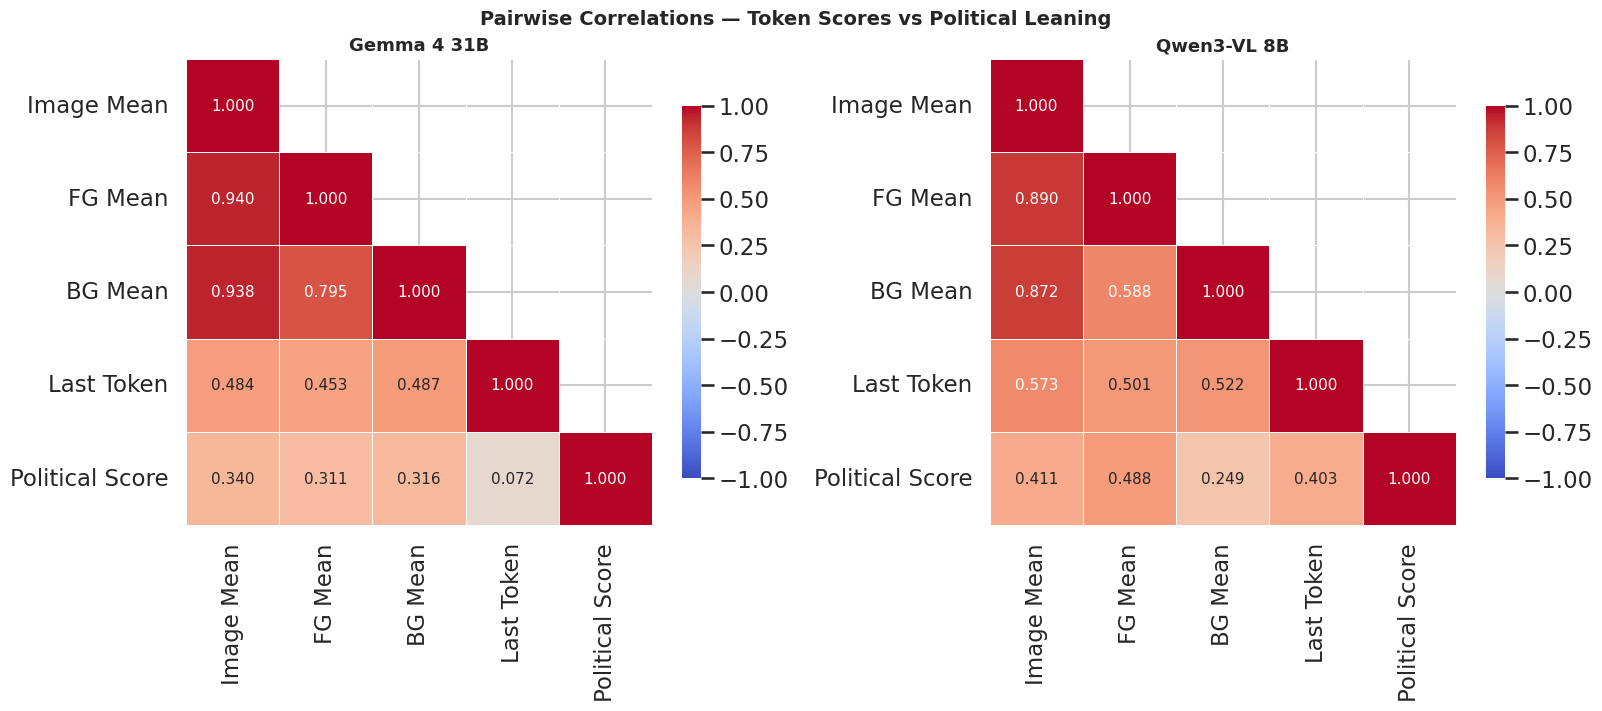

In [14]:
FIG, AXES = plt.subplots(1, len(MODELS), figsize=(8 * len(MODELS), 7), constrained_layout=True)
if len(MODELS) == 1:
    AXES = [AXES]

SCORE_COLS = ["image_mean", "image_fg_mean", "image_bg_mean", "all_last_token_score", "political_score"]
SCORE_LABELS = ["Image Mean", "FG Mean", "BG Mean", "Last Token", "Political Score"]

for ax, model in zip(AXES, MODELS):
    df = dfs[model]
    available = [c for c in SCORE_COLS if c in df.columns]
    labels = [l for c, l in zip(SCORE_COLS, SCORE_LABELS) if c in df.columns]

    corr = df[available].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.heatmap(
        corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
        vmin=-1, vmax=1, square=True, linewidths=0.5,
        mask=mask, cbar_kws={"shrink": 0.8},
        xticklabels=labels, yticklabels=labels, ax=ax,
        annot_kws={"fontsize": 11},
    )
    model_label = "Gemma 4 31B" if model == "gemma4" else "Qwen3-VL 8B"
    ax.set_title(f"{model_label}", fontweight="bold", fontsize=13)

FIG.suptitle("Pairwise Correlations — Token Scores vs Political Leaning", fontweight="bold", fontsize=14)
plt.show()

## 3. Scatter: Token Scores vs Political Leaning

Each point = one image.  X-axis: ideology scores.  Y-axis: LLM political lean ($-1$ = LEFT, $+1$ = RIGHT).
One row per model, columns: image mean, foreground mean, background mean, last prompt token.

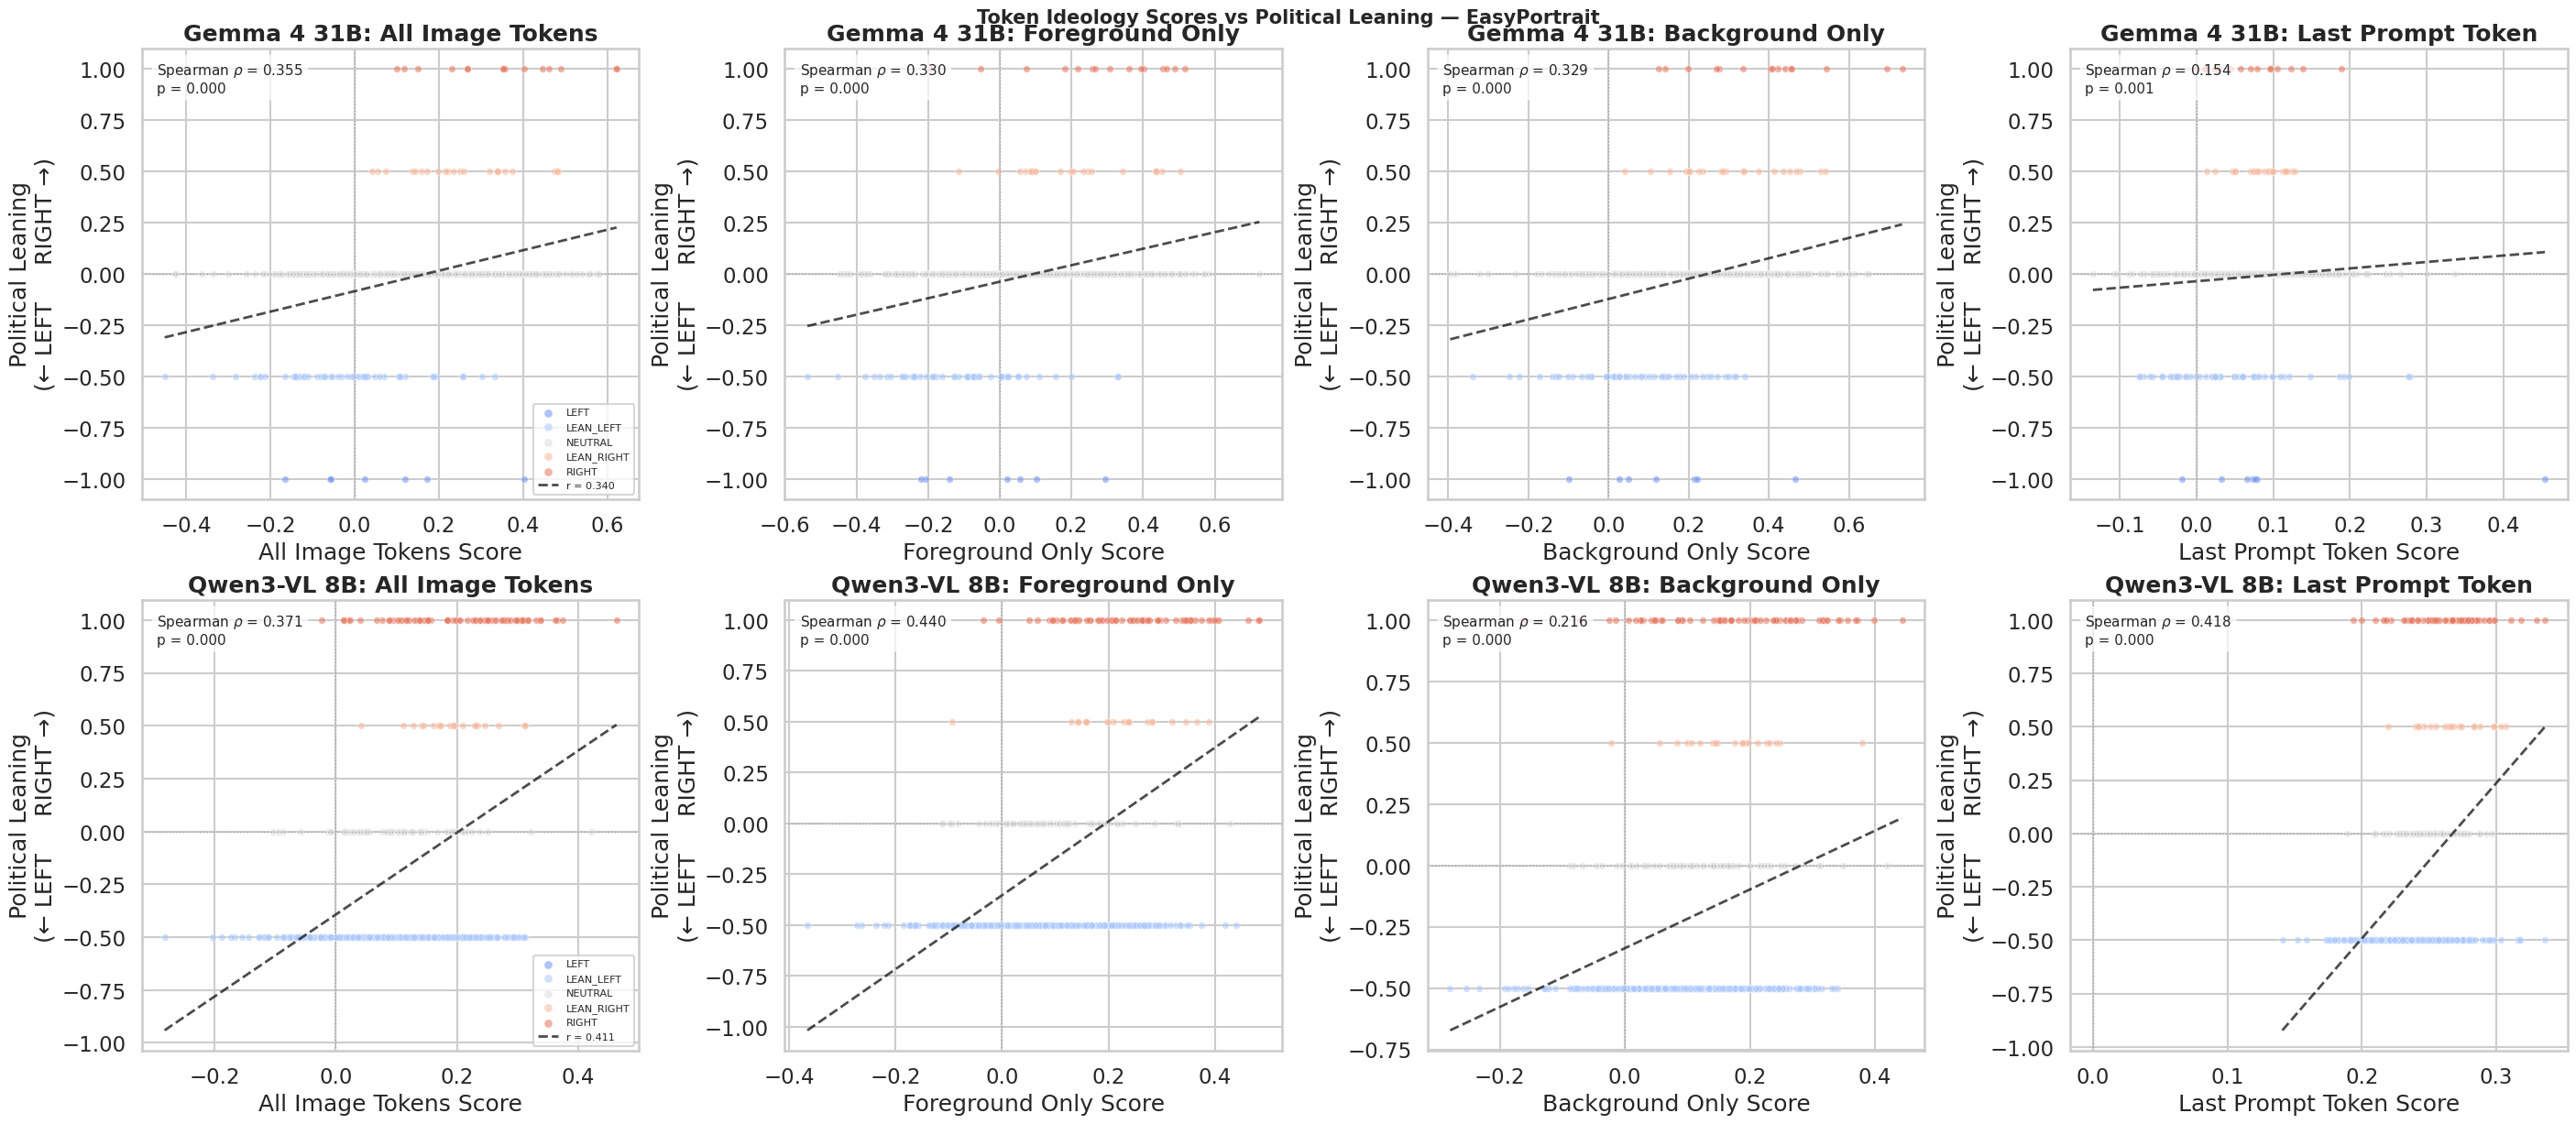

In [15]:
SCATTER_COLS = ["image_mean", "image_fg_mean", "image_bg_mean", "all_last_token_score"]
SCATTER_TITLES = ["All Image Tokens", "Foreground Only", "Background Only", "Last Prompt Token"]

FIG, AXES = plt.subplots(
    len(MODELS), len(SCATTER_COLS),
    figsize=(7 * len(SCATTER_COLS), 6 * len(MODELS)),
    constrained_layout=True,
)
if len(MODELS) == 1:
    AXES = AXES.reshape(1, -1)

LABEL_VALS = ["LEFT", "LEAN_LEFT", "NEUTRAL", "LEAN_RIGHT", "RIGHT"]
PALETTE = sns.color_palette("coolwarm", 5)

for row_idx, model in enumerate(MODELS):
    df = dfs[model]
    model_label = "Gemma 4 31B" if model == "gemma4" else "Qwen3-VL 8B"

    for col_idx, (col, title) in enumerate(zip(SCATTER_COLS, SCATTER_TITLES)):
        ax = AXES[row_idx][col_idx]
        if col not in df.columns:
            ax.set_title(f"{title}\n(column not found)")
            continue

        for label, color in zip(LABEL_VALS, PALETTE):
            mask = df["political_label"] == label
            ax.scatter(
                df.loc[mask, col], df.loc[mask, "political_score"],
                s=30, alpha=0.55, color=color, edgecolors="white",
                linewidth=0.5, label=label,
            )

        valid = df[[col, "political_score"]].dropna()
        if len(valid) > 1:
            x, y = valid[col], valid["political_score"]
            slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, slope * xs + intercept, "k--", linewidth=2, alpha=0.7,
                    label=f"r = {r_val:.3f}")

            spearman_r, spearman_p = stats.spearmanr(x, y)
            ax.text(0.03, 0.97,
                    f"Spearman $\\rho$ = {spearman_r:.3f}\np = {spearman_p:.3f}",
                    transform=ax.transAxes, fontsize=11, va="top",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

        ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.6)
        ax.axvline(0, color="gray", linestyle=":", linewidth=1, alpha=0.6)
        ax.set_title(f"{model_label}: {title}", fontweight="bold")
        ax.set_xlabel(f"{title} Score")
        ax.set_ylabel("Political Leaning\n(← LEFT     RIGHT →)")
        if col_idx == 0:
            ax.legend(loc="lower right", fontsize=8, markerscale=1.2)

FIG.suptitle("Token Ideology Scores vs Political Leaning — EasyPortrait",
             fontweight="bold", fontsize=15, y=1.01)
plt.show()

## 4. Token Score Distributions by Political Label

Boxplots for image mean, foreground mean, background mean, and last prompt token split by political label.

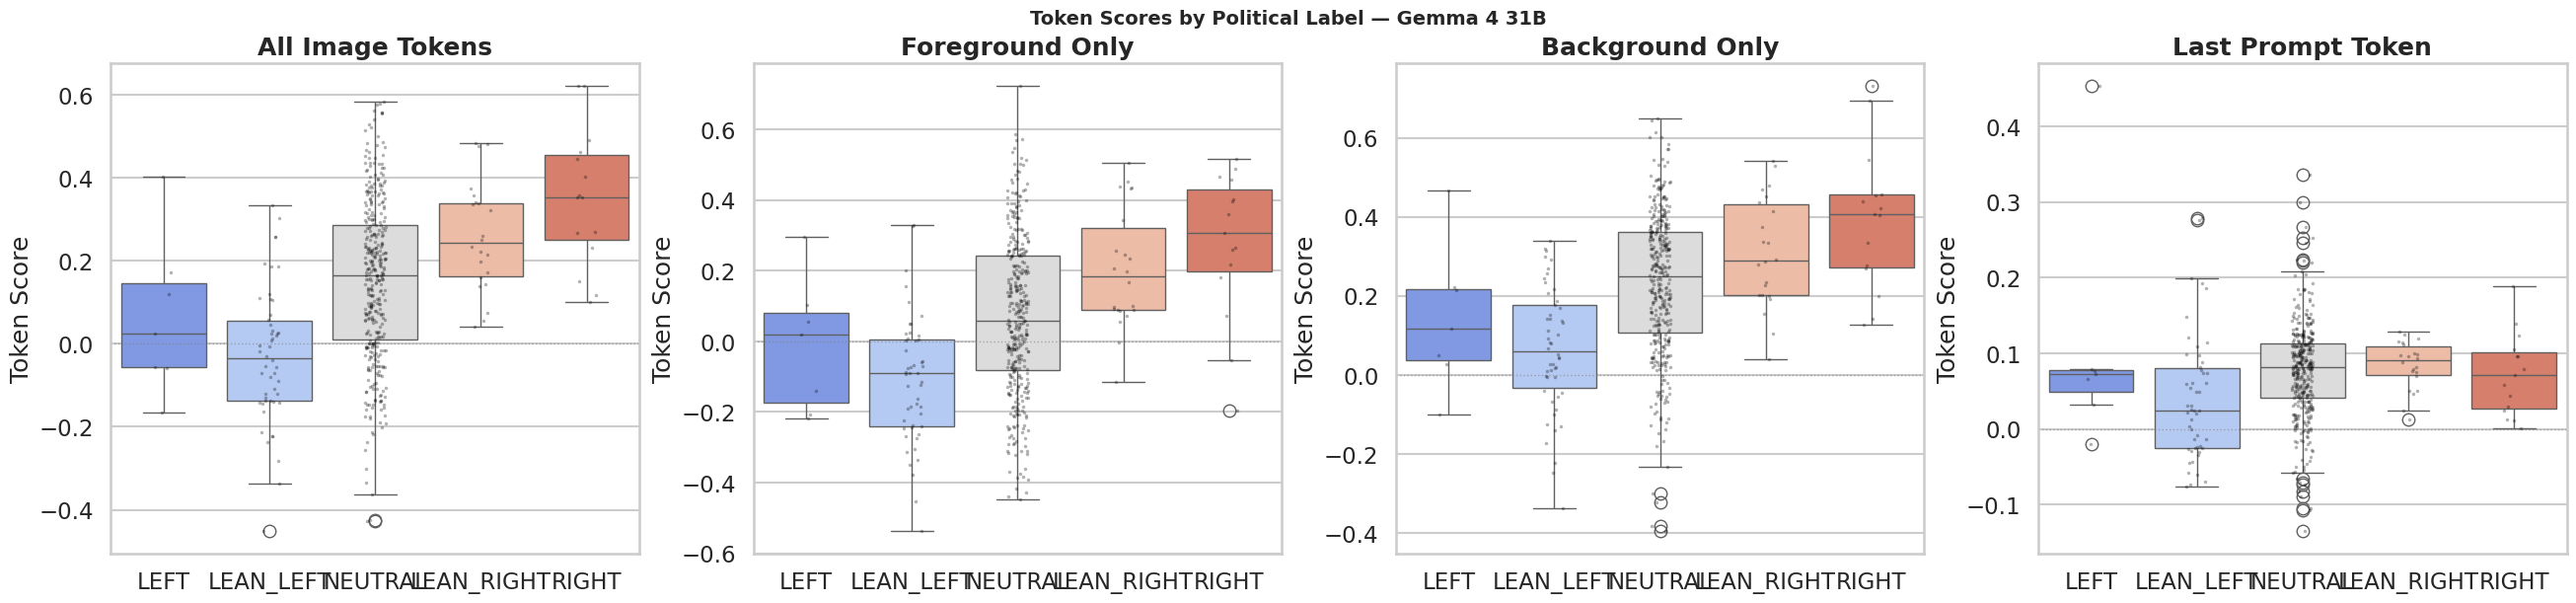

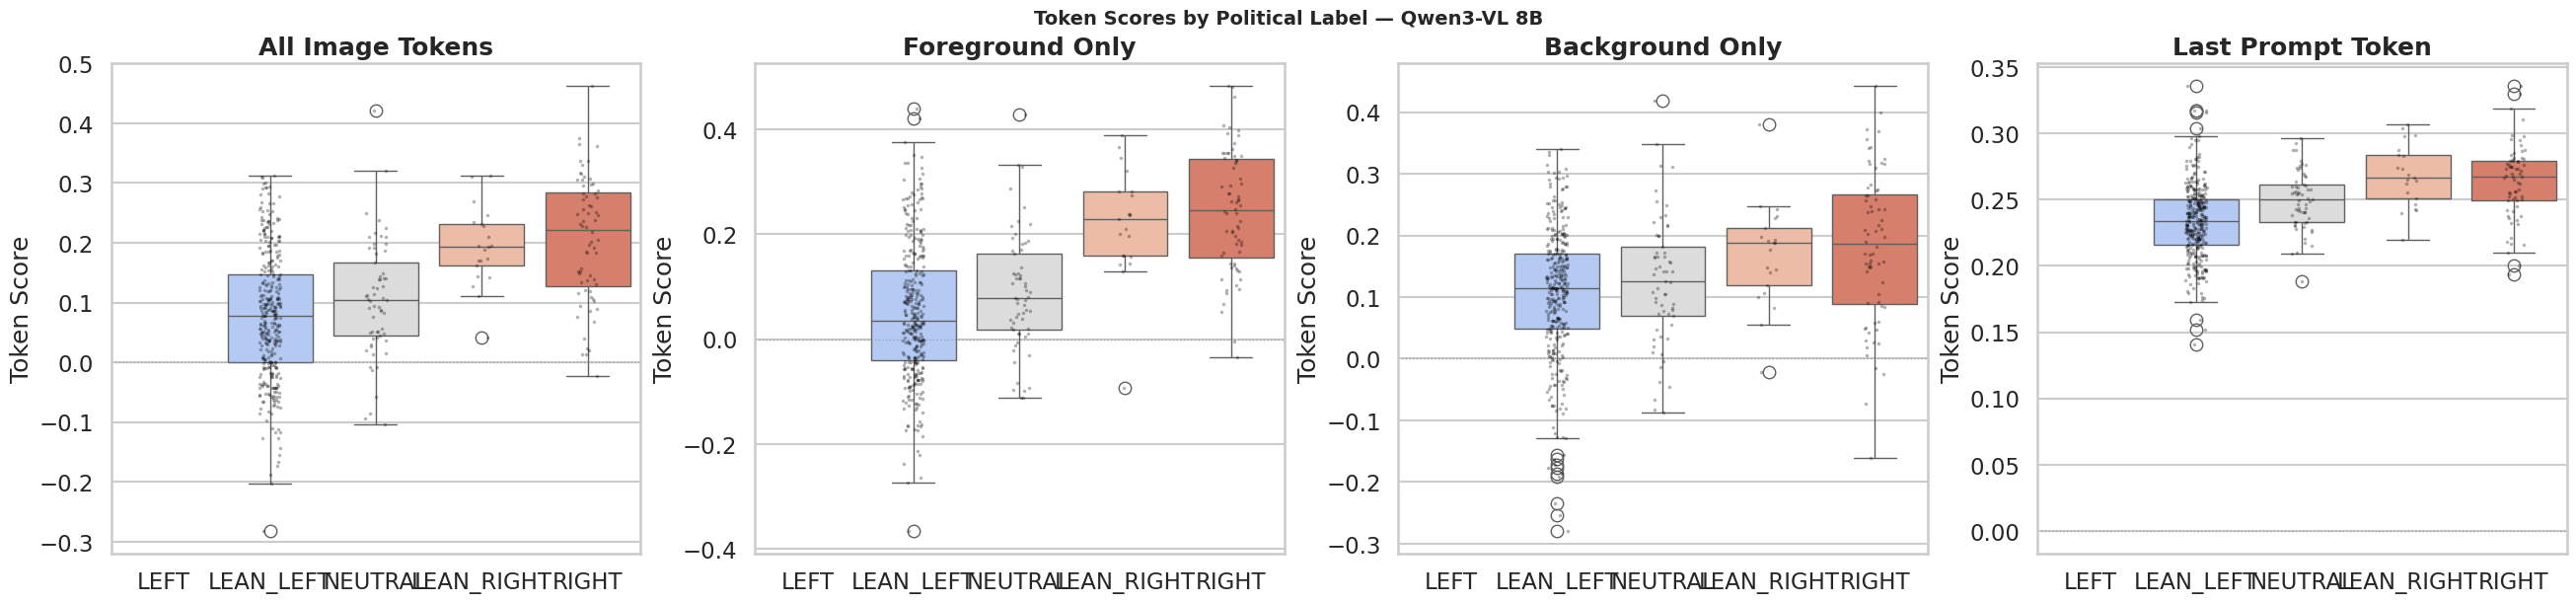

In [16]:
LABEL_ORDER = ["LEFT", "LEAN_LEFT", "NEUTRAL", "LEAN_RIGHT", "RIGHT"]
BOX_COLS = ["image_mean", "image_fg_mean", "image_bg_mean", "all_last_token_score"]
BOX_TITLES = ["All Image Tokens", "Foreground Only", "Background Only", "Last Prompt Token"]

for model in MODELS:
    df = dfs[model].copy()
    if "political_label" not in df.columns:
        continue
    df["political_label"] = pd.Categorical(df["political_label"], categories=LABEL_ORDER, ordered=True)
    df = df.sort_values("political_label")
    model_label = "Gemma 4 31B" if model == "gemma4" else "Qwen3-VL 8B"

    FIG, AXES = plt.subplots(1, 4, figsize=(26, 6), constrained_layout=True)

    for ax, col, title in zip(AXES, BOX_COLS, BOX_TITLES):
        if col not in df.columns:
            continue
        sns.boxplot(data=df, x="political_label", y=col, ax=ax,
                    palette="coolwarm", hue="political_label", legend=False, dodge=False)
        sns.stripplot(data=df, x="political_label", y=col, ax=ax,
                      color="black", size=2.5, alpha=0.3, jitter=True)
        ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.6)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Token Score")

    FIG.suptitle(f"Token Scores by Political Label — {model_label}", fontweight="bold", fontsize=14)
    plt.show()

## 5. FG − BG Score Gap by Political Label

Difference between foreground and background mean scores.

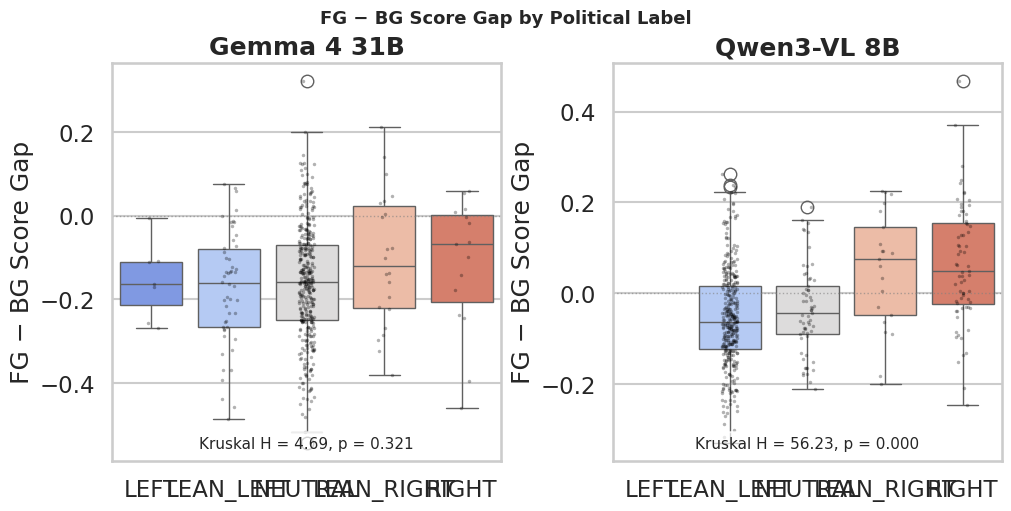

In [17]:
FIG, AXES = plt.subplots(1, len(MODELS), figsize=(10, 5), constrained_layout=True)
if len(MODELS) == 1:
    AXES = [AXES]

for ax, model in zip(AXES, MODELS):
    df = dfs[model].copy()
    if "image_fg_mean" not in df.columns or "image_bg_mean" not in df.columns:
        continue
    df["fg_bg_gap"] = df["image_fg_mean"] - df["image_bg_mean"]
    df["political_label"] = pd.Categorical(df["political_label"], categories=LABEL_ORDER, ordered=True)
    df = df.sort_values("political_label")

    model_label = "Gemma 4 31B" if model == "gemma4" else "Qwen3-VL 8B"

    sns.boxplot(data=df, x="political_label", y="fg_bg_gap", ax=ax,
                palette="coolwarm", hue="political_label", legend=False, dodge=False)
    sns.stripplot(data=df, x="political_label", y="fg_bg_gap", ax=ax,
                  color="black", size=2.5, alpha=0.3, jitter=True)
    ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_title(f"{model_label}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("FG − BG Score Gap")

    groups = [g.dropna() for _, g in df.groupby("political_label")["fg_bg_gap"]]
    if len(groups) > 1:
        h, p = stats.kruskal(*groups)
        ax.text(0.5, 0.03, f"Kruskal H = {h:.2f}, p = {p:.3f}",
                transform=ax.transAxes, fontsize=11, ha="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

FIG.suptitle("FG − BG Score Gap by Political Label", fontweight="bold", fontsize=13)
plt.show()